# Student Performance Dataset Analysis

## AIML Internship - Week 1

### Objective

The objective of this project is to analyze student academic performance using demographic and educational factors, perform data cleaning, generate insights, and prepare the dataset for further analysis and visualization.

## Dataset Source

Dataset: Students Performance in Exams

Source:
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

The dataset contains demographic information and examination scores of students across Mathematics, Reading, and Writing subjects.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../data/raw/StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Dataset Preview

In [3]:
print("First 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

First 5 Rows


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Last 5 Rows


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


# Dataset Shape

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 8


### Observation

The dataset contains 1000 rows and 8 columns.
This provides sufficient records for exploratory analysis.

# Data Type Analysis

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


# Missing Value Analysis

In [6]:
print("Total Missing Values:")
print(df.isnull().sum())

Total Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


# Duplicate Records

In [7]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

# Feature Understanding

| Feature | Type | Description |
|----------|----------|----------|
| gender | Categorical | Gender of the student |
| race/ethnicity | Categorical | Ethnicity group of the student |
| parental level of education | Categorical | Highest education level attained by parents |
| lunch | Categorical | Type of lunch received by the student |
| test preparation course | Categorical | Indicates whether the student completed a preparation course |
| math score | Numerical | Mathematics examination score |
| reading score | Numerical | Reading examination score |
| writing score | Numerical | Writing examination score |

# Data Cleaning Workflow

The following steps were performed:

1. Loaded the dataset.
2. Inspected rows and columns.
3. Verified data types.
4. Checked for missing values.
5. Checked for duplicate records.
6. Standardized column names.
7. Created a new AverageScore feature.
8. Exported the cleaned dataset.

In [9]:
df["AverageScore"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

# Target Variable

Target Variable: AverageScore

Reason:

The dataset contains three academic performance indicators:
- Math Score
- Reading Score
- Writing Score

To provide a single overall measure of academic performance, an AverageScore feature was created by averaging all three examination scores.

This variable will be used as the primary performance indicator throughout the analysis.

In [10]:
print("Total Missing Values:")
print(df.isnull().sum())

Total Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
AverageScore                   0
dtype: int64


### Missing Value Analysis

No missing values were identified in the dataset.

Therefore, no imputation or record removal was required.

In [11]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


### Duplicate Record Analysis

No duplicate records were found in the dataset.

Therefore, no duplicate removal was required.

In [12]:
df.columns = [
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "LunchType",
    "TestPreparation",
    "MathScore",
    "ReadingScore",
    "WritingScore",
    "AverageScore"
]

In [13]:
df.head()

,Gender,Ethnicity,ParentalEducation,LunchType,TestPreparation,MathScore,ReadingScore,WritingScore,AverageScore
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


### Column Standardization

Column names were standardized to improve readability and simplify analysis.

Spaces were removed and descriptive naming conventions were applied.

In [14]:
df.to_csv(
    "../data/cleaned/students_performance_cleaned.csv",
    index=False
)

### Cleaned Dataset Export

The cleaned dataset was saved separately to preserve the original raw dataset.

File:
data/cleaned/students_performance_cleaned.csv

In [15]:
df.describe()

,MathScore,ReadingScore,WritingScore,AverageScore
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


# Descriptive Statistics Interpretation

The dataset contains 1000 student records with performance scores across Mathematics, Reading, and Writing subjects.

The average Mathematics score is 66.09, while the average Reading and Writing scores are 69.17 and 68.05 respectively.

Reading scores show the highest average performance among the three subjects.

The average overall performance score (AverageScore) is approximately 67.77.

The standard deviation values indicate moderate variation in student performance across all subjects.

The minimum and maximum values show a wide range of performance levels, from very low scores to perfect scores.

The median scores are close to the mean values, suggesting relatively balanced score distributions without severe skewness.

# Key Observations

### Observation 1
The dataset contains 1000 student records and 8 original features, providing sufficient data for exploratory analysis.

### Observation 2
No missing values were detected in the dataset, indicating high data quality and reducing the need for preprocessing interventions.

### Observation 3
No duplicate records were found, suggesting that each row represents a unique student record.

### Observation 4
Reading scores have the highest average value (69.17), indicating that students generally performed slightly better in reading compared to mathematics and writing.

### Observation 5
Mathematics scores have the lowest average score (66.09) among the three subjects, suggesting that students may find mathematics relatively more challenging than reading and writing.

### Observation 6
The average overall student performance score is approximately 67.77, indicating moderate academic achievement across the dataset.

### Observation 7
The standard deviation values are relatively similar across all subjects, suggesting comparable variability in student performance.

### Observation 8
The presence of both very low and perfect scores demonstrates significant performance differences among students.

# Dataset Summary

The Students Performance dataset contains demographic and academic information for 1000 students.

The dataset includes five categorical features:
- Gender
- Ethnicity
- Parental Education
- Lunch Type
- Test Preparation Status

The dataset also contains three numerical performance indicators:
- Mathematics Score
- Reading Score
- Writing Score

An additional AverageScore feature was created to represent overall academic performance and serve as the primary target variable for analysis.

In [16]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
female    518
male      482
Name: count, dtype: int64

Ethnicity
Ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

ParentalEducation
ParentalEducation
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

LunchType
LunchType
standard        645
free/reduced    355
Name: count, dtype: int64

TestPreparation
TestPreparation
none         642
completed    358
Name: count, dtype: int64


C:\Users\Kashish Birju\AppData\Local\Temp\ipykernel_18164\3184382529.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [17]:
df.groupby("TestPreparation")["AverageScore"].mean()

TestPreparation
completed    72.669460
none         65.038941
Name: AverageScore, dtype: float64

### Observation 9

Students who completed the test preparation course achieved an average score of 72.67, while students who did not complete the course achieved an average score of 65.04.

This suggests that participation in preparation programs may be associated with improved academic performance.

# Data Cleaning Summary

The following data quality checks were performed:

1. Dataset structure and dimensions were inspected.
2. Data types were verified.
3. Missing value analysis was performed.
4. Duplicate record analysis was performed.
5. Column names were standardized for readability.
6. An AverageScore feature was created to represent overall student performance.
7. The cleaned dataset was exported separately to preserve the original dataset.

Results:

- Missing Values Found: 0
- Duplicate Records Found: 0
- New Feature Created: AverageScore
- Cleaned Dataset Exported Successfully

# Conclusion

The dataset was successfully inspected, cleaned, and analyzed.

No missing values or duplicate records were identified, indicating high-quality data.

Reading scores demonstrated the highest average performance, while mathematics showed comparatively lower performance levels.

Students who completed test preparation courses achieved significantly higher average scores than those who did not participate, suggesting that preparation activities may contribute positively to academic outcomes.

The cleaned dataset is now ready for visualization and deeper exploratory analysis.

# Task 2: Data Visualization Project

## Objective

The objective of this section is to transform the cleaned student performance dataset into meaningful visualizations and identify patterns, relationships, and trends that may influence academic performance.

## Visualization 1: Distribution of Average Scores

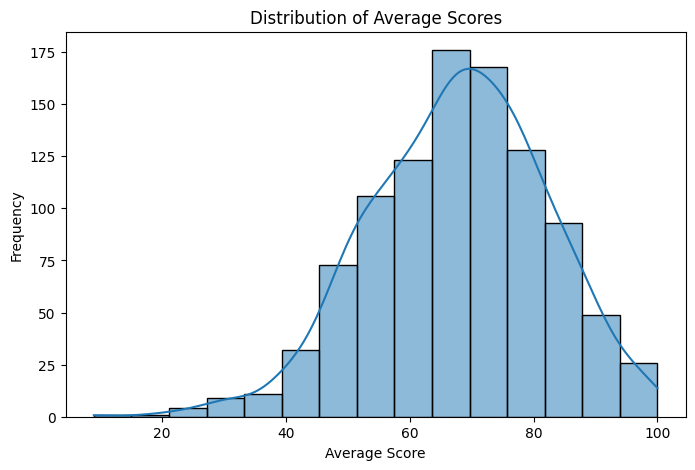

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["AverageScore"],
    bins=15,
    kde=True
)

plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Frequency")

plt.savefig(
    "../outputs/charts/average_score_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

The histogram displays the distribution of student average scores.

Most students scored between 60 and 80 marks, indicating moderate academic performance across the dataset.

The distribution appears relatively balanced without extreme skewness, suggesting that performance levels are spread fairly evenly among students.

## Visualization 2: Test Preparation and Academic Performance

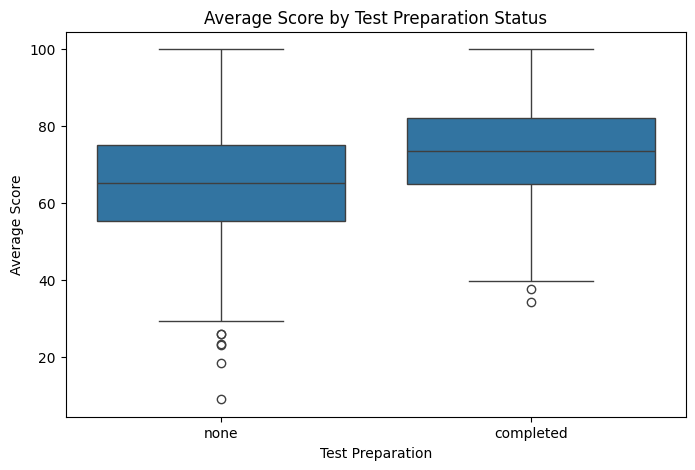

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TestPreparation",
    y="AverageScore",
    data=df
)

plt.title("Average Score by Test Preparation Status")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")

plt.savefig(
    "../outputs/charts/test_preparation_boxplot.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

Students who completed the test preparation course generally achieved higher average scores than those who did not.

The median score of students who completed preparation is noticeably higher, suggesting that preparation activities may positively influence academic performance.

## Visualization 3: Reading Score vs Writing Score

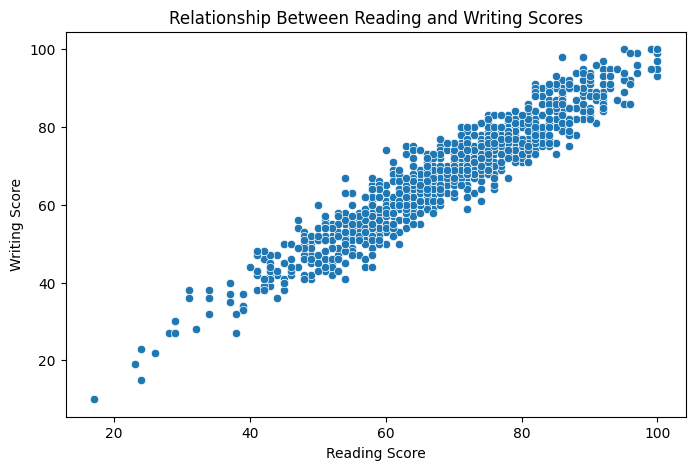

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="ReadingScore",
    y="WritingScore",
    data=df
)

plt.title("Relationship Between Reading and Writing Scores")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")

plt.savefig(
    "../outputs/charts/reading_writing_scatter.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

The scatter plot demonstrates a strong positive relationship between reading and writing scores.

Students with higher reading scores generally tend to achieve higher writing scores, indicating that both skills may be closely related.

## Visualization 4: Correlation Analysis

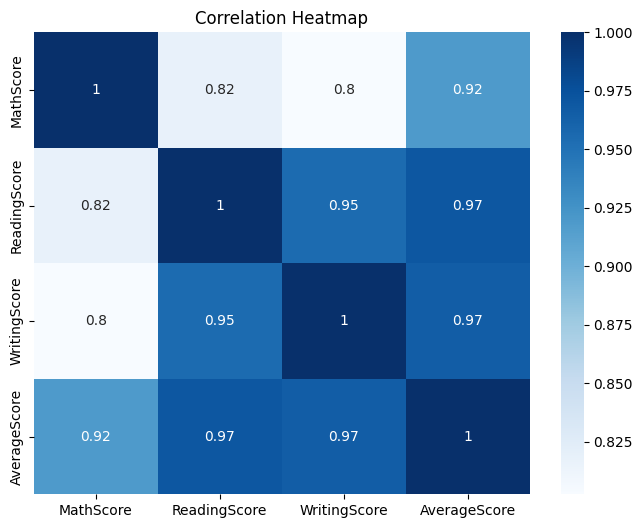

In [21]:
corr = df.select_dtypes(
    include="number"
).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../outputs/charts/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

The heatmap shows strong positive correlations among Mathematics, Reading, Writing, and Average Score.

Reading and Writing scores exhibit one of the strongest relationships, suggesting that students who perform well in reading often perform well in writing.

Correlation indicates association and should not be interpreted as causation.

## Visualization 5: Parental Education and Performance

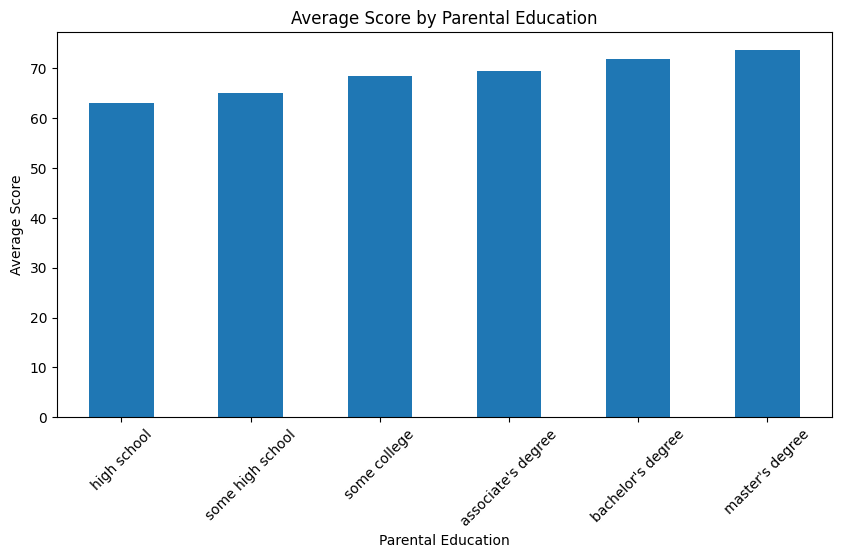

In [22]:
plt.figure(figsize=(10,5))

avg_scores = df.groupby(
    "ParentalEducation"
)["AverageScore"].mean().sort_values()

avg_scores.plot(kind="bar")

plt.title(
    "Average Score by Parental Education"
)

plt.xlabel(
    "Parental Education"
)

plt.ylabel(
    "Average Score"
)

plt.xticks(rotation=45)

plt.savefig(
    "../outputs/charts/parental_education_barplot.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

Students whose parents have higher education levels generally show slightly better average academic performance.

This may suggest that parental educational background can influence student learning outcomes, although additional factors may also contribute.

# Key Visualization Insights

1. Average student performance is concentrated between 60 and 80 marks.

2. Students who completed test preparation courses achieved significantly higher scores.

3. Reading and writing scores demonstrate a very strong positive relationship.

4. Academic subject scores are strongly correlated with overall performance.

5. Students with more highly educated parents tend to achieve slightly higher academic scores.

# Task 2 Conclusion

The visualizations revealed several meaningful patterns within the dataset.

Students who completed test preparation courses achieved higher average scores.

Reading and writing scores demonstrated a strong positive relationship.

Correlation analysis showed that all academic performance indicators were positively associated with one another.

These findings provide valuable insight into factors that may influence student academic outcomes.